In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.Propeller import Propeller
from src.JobParameters import AerodynamicParameters, AcousticParameters

with open("../10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

In [2]:
aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=1000, num_obs_times_per_rev=100
)

In [3]:
v_inf = 0*np.ones(len(blade_dict['r']))

In [4]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)

propeller.run_bemt(v_inf=v_inf)

In [5]:
Ts,Qs, _, _ = propeller.compute_total_forces()

history_dTs, history_dQs = propeller.solution_data['dT'].values, propeller.solution_data['dQ'].values

BEMT Results: Thrust=8.2330 N, Torque=0.1373 N·m, Ct=0.118630, Cp=0.048952


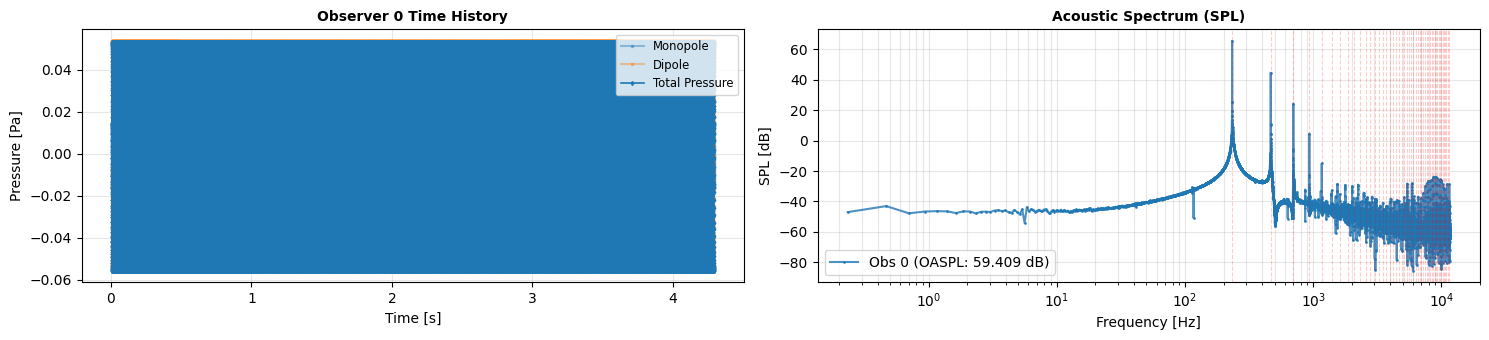

In [6]:
import matplotlib.gridspec as gridspec

# r_observer = np.array([[0, 1.88, 0],
#                         [0, 0, 1.88]])
r_observer = np.array([[0, 1.88, 0]])
                      
propeller.run_compact_f1a(observer_positions=r_observer, use_GPU=True)
t_no_turb = propeller.t.copy()
p_no_turb = propeller.p_tot.copy()
# Performance output
thrust, torque, ct, cp = propeller.compute_total_forces()
print(f"BEMT Results: Thrust={thrust:.4f} N, Torque={torque:.4f} N·m, Ct={ct:.6f}, Cp={cp:.6f}")

n_obs = r_observer.shape[0]
fig = plt.figure(figsize=(15, 3.5 * n_obs)) 
gs = gridspec.GridSpec(n_obs, 2, figure=fig)

fontsize = 10
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
blade_passing_freq = 1 / acoustic_params.blade_passing_period

ax_spl = fig.add_subplot(gs[:, 1])

for idx in range(n_obs):
    ax_time = fig.add_subplot(gs[idx, 0])
    color = colors[idx % len(colors)]
    
    ax_time.plot(propeller.t[:, idx], propeller.p_m[:, idx], 
                label='Monopole', linestyle='-', marker='o', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_d[:, idx], 
                label='Dipole', linestyle='-', marker='s', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_tot[:, idx], 
                color=color, linestyle='-', marker='d', markersize=2, 
                linewidth=1.2, label='Total Pressure')
    
    ax_time.set_title(f'Observer {idx} Time History', fontsize=fontsize, fontweight='bold')
    ax_time.set_xlabel('Time [s]', fontsize=fontsize)
    ax_time.set_ylabel('Pressure [Pa]', fontsize=fontsize)
    ax_time.grid(True, alpha=0.3)
    ax_time.legend(loc='upper right', fontsize='small')

    label_text = f'Obs {idx} (OASPL: {propeller.oaspl[idx]:.3f} dB)'
    
    ax_spl.semilogx(propeller.freq[1:, idx], propeller.spl[1:, idx], 
                    color=color, linestyle='-', marker='.', markersize=2, 
                    label=label_text, alpha=0.8)

ax_spl.set_title('Acoustic Spectrum (SPL)', fontsize=fontsize, fontweight='bold')
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('SPL [dB]', fontsize=fontsize)

max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    ax_spl.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
ax_spl.set_ylim()
plt.tight_layout()
plt.show()

In [ ]:
import torch

def generate_3d_von_karman(Lx, Ly, Lz, nx, ny, nz, sigma, L_scale, device='cuda'):
    # 1. Setup wavenumbers (Using torch.fft.fftfreq)
    kx = 2 * torch.pi * torch.fft.fftfreq(nx, d=Lx/nx, device=device)
    ky = 2 * torch.pi * torch.fft.fftfreq(ny, d=Ly/ny, device=device)
    kz = 2 * torch.pi * torch.fft.fftfreq(nz, d=Lz/nz, device=device)
    
    # Create meshgrid on device
    KX, KY, KZ = torch.meshgrid(kx, ky, kz, indexing='ij')
    K = torch.sqrt(KX**2 + KY**2 + KZ**2)
    
    # 2. Von Karman Energy Spectrum
    # Avoid division by zero at the origin
    K_sq = K**2
    L_sq_K_sq = (L_scale**2) * K_sq
    
    # Standard isotropic formulation
    E_k = (1.4528 * sigma**2 * L_scale * (L_sq_K_sq)**2) / (1 + L_sq_K_sq)**(17/6)
    
    # Avoid NaN at K=0
    psd = E_k / (4 * torch.pi * K_sq)
    psd[0, 0, 0] = 0
    
    # 3. Generate 3D box via IFFT
    # Note: Use complex64 for efficiency unless you need extreme precision
    noise = torch.randn((nx, ny, nz), dtype=torch.complex64, device=device)
    
    # Filter and transform
    box_complex = torch.fft.ifftn(torch.sqrt(psd) * noise)
    box = box_complex.real
    
    # Normalize
    box = (box - box.mean()) / box.std() * sigma
    return box

Ly, Lz = 0.3, 0.3     
Lx = 2 * propeller.solution_data.u.values.mean() * propeller.acoustic_params.revolutions * 60 / propeller.aero_params.rpm             

ny, nz = 100, 100
nx = int(100 * Lx)

sigma = 0.8  # Turbulence intensity (m/s)         
# L_scale: Set to 1/2 of diameter to see spatial variation across blades
L_scale = propeller.aero_params.prop_radius / 2       

u_box = generate_3d_von_karman(Lx, Ly, Lz, nx, ny, nz, sigma, L_scale).cpu().numpy()

nx, ny, nz = u_box.shape

from scipy.interpolate import RegularGridInterpolator

interp = RegularGridInterpolator(
    (np.linspace(0, Lx, nx), np.linspace(-Ly/2, Ly/2, ny), np.linspace(-Lz/2, Lz/2, nz)),
    u_box, bounds_error=False, fill_value=0
)

TypeError: Cannot interpret 'torch.float32' as a data type

In [ ]:
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

aero = propeller.aero_params
acoust = propeller.acoustic_params
df = propeller.solution_data

# Extract BEMT vectors
r = df['radius'].values
u_steady = df['u'].values

x_pos = 0.0 

current_vi = u_steady

history_dT = np.zeros((len(propeller.acoustic_params.src_times), aero.n_blades, len(r)))
history_dQ = np.zeros((len(propeller.acoustic_params.src_times), aero.n_blades, len(r)))

azimuth = propeller.aero_params.omega * propeller.acoustic_params.src_times[:, None] + (2 * np.pi * np.array(range(propeller.aero_params.n_blades))[None, :] / propeller.aero_params.n_blades)
y_pts = r[None, None, :] * np.cos(azimuth[:, :, None])
z_pts = r[None, None, :] * np.sin(azimuth[:, :, None])

# --- 2. The Unsteady Loop ---
for i, t in enumerate(propeller.acoustic_params.src_times):
    # Determine the adaptive advection speed
    # V_scan = V_inf + Average induced velocity across the disk
    v_avg_induced = np.average(current_vi)
    v_scan_current = v_inf[0] + v_avg_induced
    
    # Increment x position based on the velocity of the current time step
    # x = integral of (V_inf + vi) dt
    x_pos += v_scan_current * propeller.acoustic_params.dt
    for b in range(aero.n_blades):
        query_pts = np.vstack(([x_pos]*len(r), y_pts[i, b], z_pts[i, b])).T
        u_prime = interp(query_pts)
        
        # Run BEMT with the turbulent local v_inf
        propeller.run_bemt(v_inf = v_inf[0] + u_prime)
        current_vi = propeller.solution_data['u'].values
        
        history_dT[i, b, :] = propeller.solution_data['dT'].values/aerodynamic_params.n_blades
        history_dQ[i, b, :] = propeller.solution_data['dQ'].values/aerodynamic_params.n_blades

    T, Q, _, _ = propeller.compute_total_forces()
    if i % 100 == 0:
        print(f"Step {i+1}/{len(propeller.acoustic_params.src_times)} | V_scan: {v_scan_current:.3f} m/s | Total T: {T:.4f} N | Total Q: {Q:.4f} N·m")

Step 1/100000 | V_scan: 8.018 m/s | Total T: 8.2009 N | Total Q: 0.1396 N·m
Step 101/100000 | V_scan: 7.754 m/s | Total T: 8.3834 N | Total Q: 0.1396 N·m
Step 201/100000 | V_scan: 7.756 m/s | Total T: 8.3580 N | Total Q: 0.1408 N·m
Step 301/100000 | V_scan: 8.203 m/s | Total T: 8.1557 N | Total Q: 0.1346 N·m
Step 401/100000 | V_scan: 8.228 m/s | Total T: 8.2532 N | Total Q: 0.1339 N·m
Step 501/100000 | V_scan: 7.743 m/s | Total T: 8.3463 N | Total Q: 0.1404 N·m
Step 601/100000 | V_scan: 7.878 m/s | Total T: 8.1712 N | Total Q: 0.1389 N·m
Step 701/100000 | V_scan: 7.641 m/s | Total T: 8.1830 N | Total Q: 0.1431 N·m
Step 801/100000 | V_scan: 7.819 m/s | Total T: 8.3329 N | Total Q: 0.1400 N·m
Step 901/100000 | V_scan: 8.033 m/s | Total T: 8.2701 N | Total Q: 0.1400 N·m
Step 1001/100000 | V_scan: 8.035 m/s | Total T: 8.1382 N | Total Q: 0.1349 N·m
Step 1101/100000 | V_scan: 8.319 m/s | Total T: 8.2534 N | Total Q: 0.1344 N·m
Step 1201/100000 | V_scan: 8.347 m/s | Total T: 8.1261 N | Total

In [ ]:
history_T = np.sum(history_dT, axis=(1,2))
history_Q = np.sum(history_dQ, axis=(1,2))

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Davide Pusino\AppData\Local\Temp\ipykernel_20280\1375162850.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Unsteady Propeller Thrust History\n(Turbulent Inflow $\sigma$={sigma} m/s)", fontsize=14)


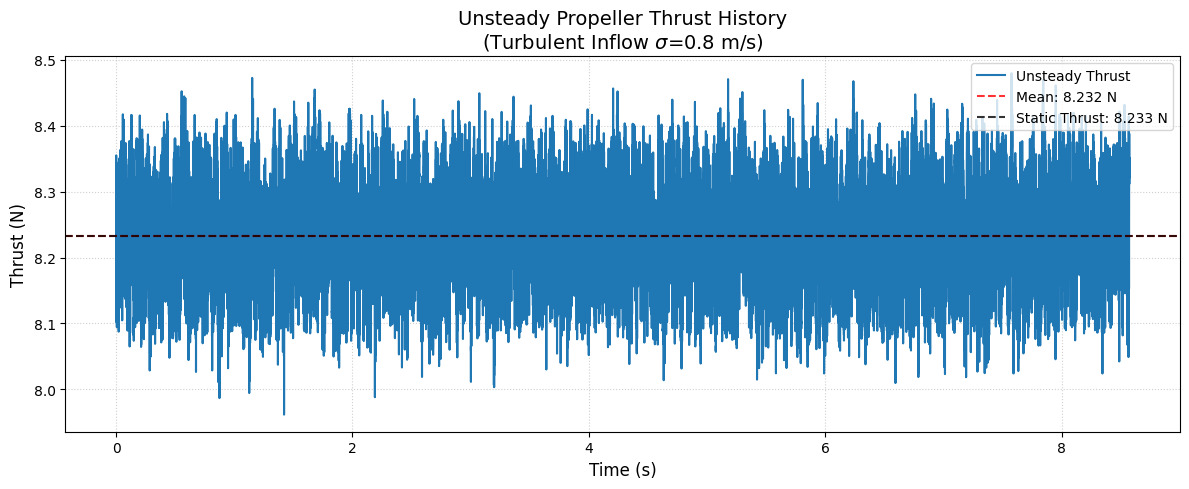

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5), dpi=100)
plt.plot(propeller.acoustic_params.src_times, history_T, label='Unsteady Thrust', color='#1f77b4', lw=1.5)
plt.axhline(y=np.mean(history_T), color='red', linestyle='--', alpha=0.8, label=f'Mean: {np.mean(history_T):.3f} N')
plt.axhline(y=Ts, color='k', linestyle='--', alpha=0.8, label=f'Static Thrust: {Ts:.3f} N')

plt.title(f"Unsteady Propeller Thrust History\n(Turbulent Inflow $\sigma$={sigma} m/s)", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Thrust (N)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

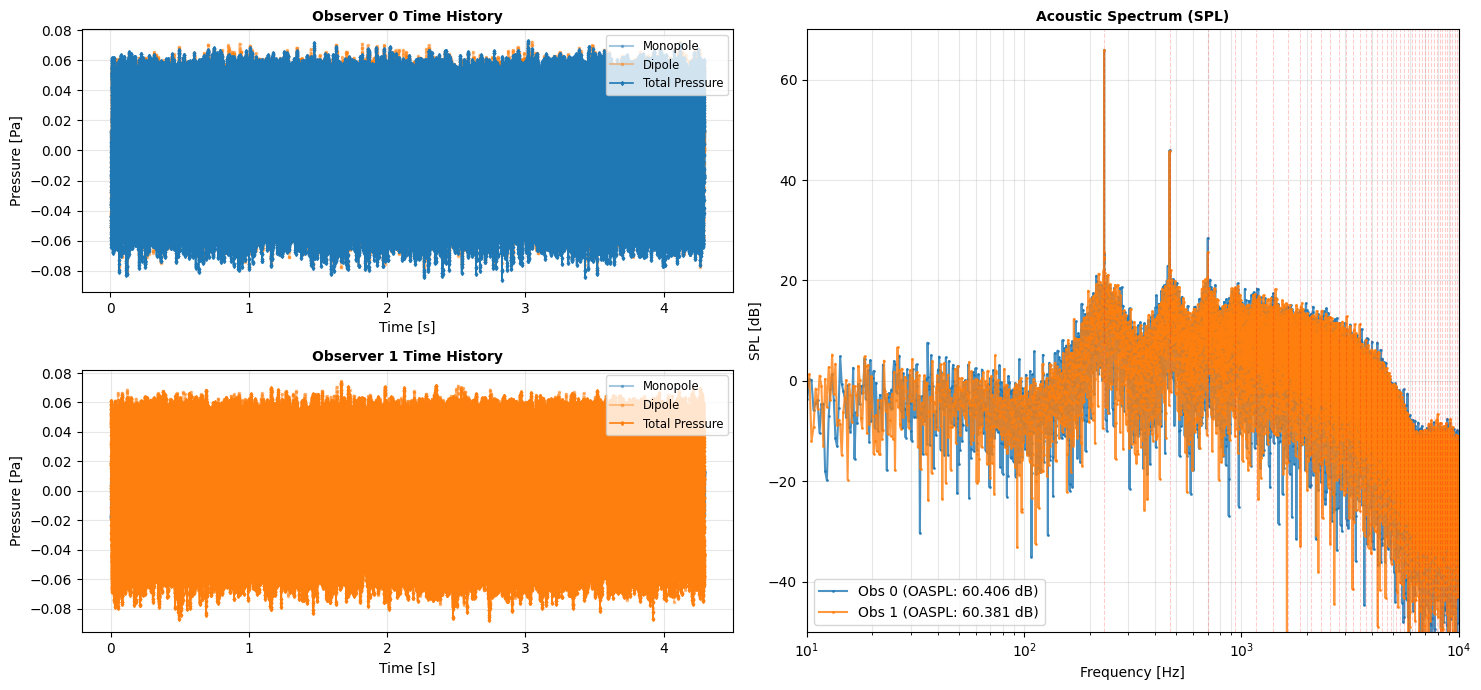

In [ ]:
import matplotlib.gridspec as gridspec

r_observer = np.array([[0, 1.88, 0],
                        [0, 0, 1.88]])

propeller.run_compact_f1a(observer_positions=r_observer, local_dT=history_dT, local_dQ=history_dQ)

n_obs = r_observer.shape[0]
fig = plt.figure(figsize=(15, 3.5 * n_obs)) 
gs = gridspec.GridSpec(n_obs, 2, figure=fig)

fontsize = 10
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
blade_passing_freq = 1 / acoustic_params.blade_passing_period

ax_spl = fig.add_subplot(gs[:, 1])

for idx in range(n_obs):
    ax_time = fig.add_subplot(gs[idx, 0])
    color = colors[idx % len(colors)]
    
    ax_time.plot(propeller.t[:, idx], propeller.p_m[:, idx], 
                label='Monopole', linestyle='-', marker='o', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_d[:, idx], 
                label='Dipole', linestyle='-', marker='s', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_tot[:, idx], 
                color=color, linestyle='-', marker='d', markersize=2, 
                linewidth=1.2, label='Total Pressure')
    
    ax_time.set_title(f'Observer {idx} Time History', fontsize=fontsize, fontweight='bold')
    ax_time.set_xlabel('Time [s]', fontsize=fontsize)
    ax_time.set_ylabel('Pressure [Pa]', fontsize=fontsize)
    ax_time.grid(True, alpha=0.3)
    ax_time.legend(loc='upper right', fontsize='small')

    label_text = f'Obs {idx} (OASPL: {propeller.oaspl[idx]:.3f} dB)'
    
    ax_spl.semilogx(propeller.freq[1:, idx], propeller.spl[1:, idx], 
                    color=color, linestyle='-', marker='.', markersize=2, 
                    label=label_text, alpha=0.8)

ax_spl.set_title('Acoustic Spectrum (SPL)', fontsize=fontsize, fontweight='bold')
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('SPL [dB]', fontsize=fontsize)

max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    ax_spl.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
ax_spl.set_xlim(10, 10000)
ax_spl.set_ylim(-50,70)
plt.tight_layout()
plt.show()

In [ ]:
import pickle
import numpy as np
with open('../10x7e_2024-11-28-13-21-17_RPM_7000.pkl', 'rb') as f:
    data = pickle.load(f)
t = data['sound']['channels']['1']['time']
p = data['sound']['channels']['1']['pressure']

p_ref = 2e-5
n = len(t)
n = t.shape[0]
dt = t[1] - t[0]
freq = np.fft.rfftfreq(n, dt)

fft_p = np.fft.rfft(p, axis=0)
fft_amp = np.abs(fft_p) * np.sqrt(2) / n
fft_amp[0] /= np.sqrt(2) 

spl = 20 * np.log10(np.maximum(fft_amp, 1e-15) / p_ref)

def r_a_func(f):
    f_sq = f**2
    return (12194**2 * f_sq**2) / (
        (f_sq + 20.6**2) * np.sqrt((f_sq + 107.7**2) * (f_sq + 737.9**2)) * (f_sq + 12194**2)
    )

a_weight = 20 * np.log10(r_a_func(freq)) - 20 * np.log10(r_a_func(1000))
spl_a = spl + a_weight

# RMS-based Overall levels
p_rms = np.sqrt(fft_amp[0]**2 + 2 * np.sum(fft_amp[1:]**2, axis=0))
ospl = 20 * np.log10(p_rms / p_ref)

amp_a = 10 ** (spl_a / 20) * p_ref
p_rms_a = np.sqrt(amp_a[0]**2 + 2 * np.sum(amp_a[1:]**2, axis=0))
oaspl = 20 * np.log10(p_rms_a / p_ref)

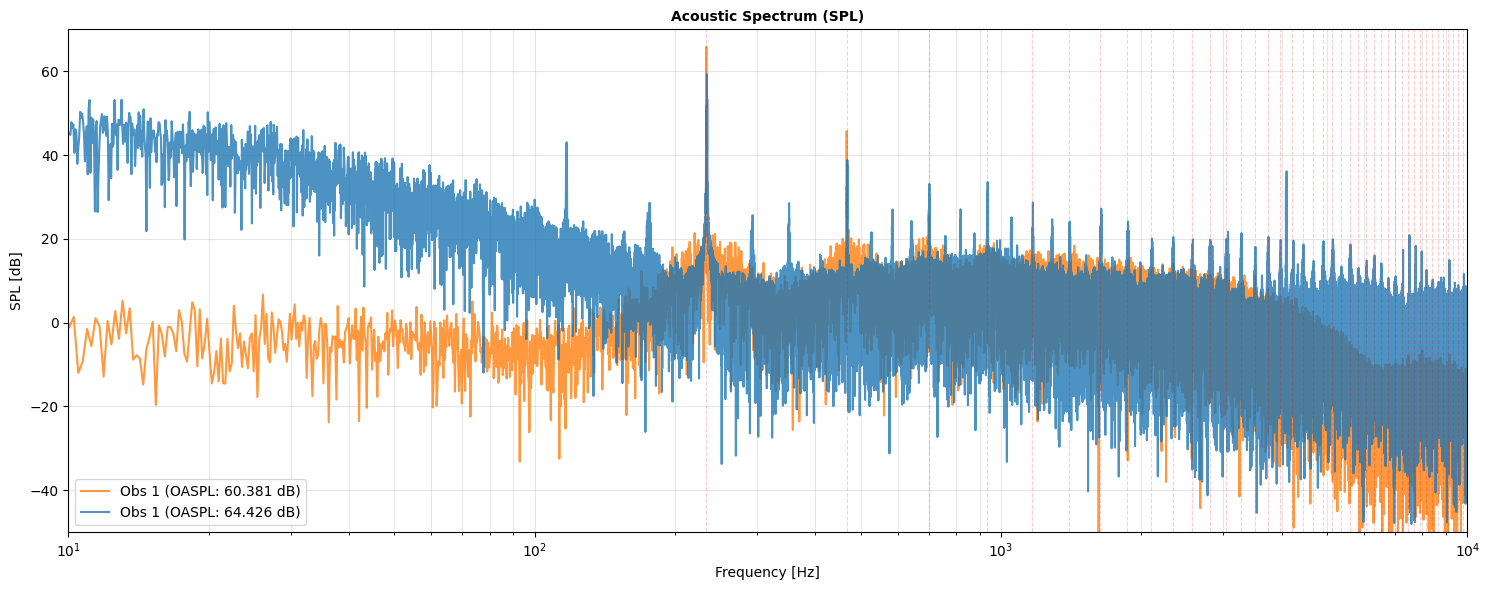

In [ ]:
fig, ax_spl = plt.subplots(figsize=(15, 6))

fontsize = 10
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
blade_passing_freq = 1 / acoustic_params.blade_passing_period

label_text = f'Obs {idx} (OASPL: {propeller.oaspl[idx]:.3f} dB)'

ax_spl.semilogx(propeller.freq[1:, idx], propeller.spl[1:, idx], 
                color=color, linestyle='-',
                label=label_text, alpha=0.8)

ax_spl.semilogx(freq, spl, linestyle='-',
                    label=f'Obs {1} (OASPL: {oaspl:.3f} dB)', alpha=0.8)

ax_spl.set_title('Acoustic Spectrum (SPL)', fontsize=fontsize, fontweight='bold')
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('SPL [dB]', fontsize=fontsize)

max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    ax_spl.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
ax_spl.set_xlim(10, 10000)
ax_spl.set_ylim(-50,70)
plt.tight_layout()
plt.show()

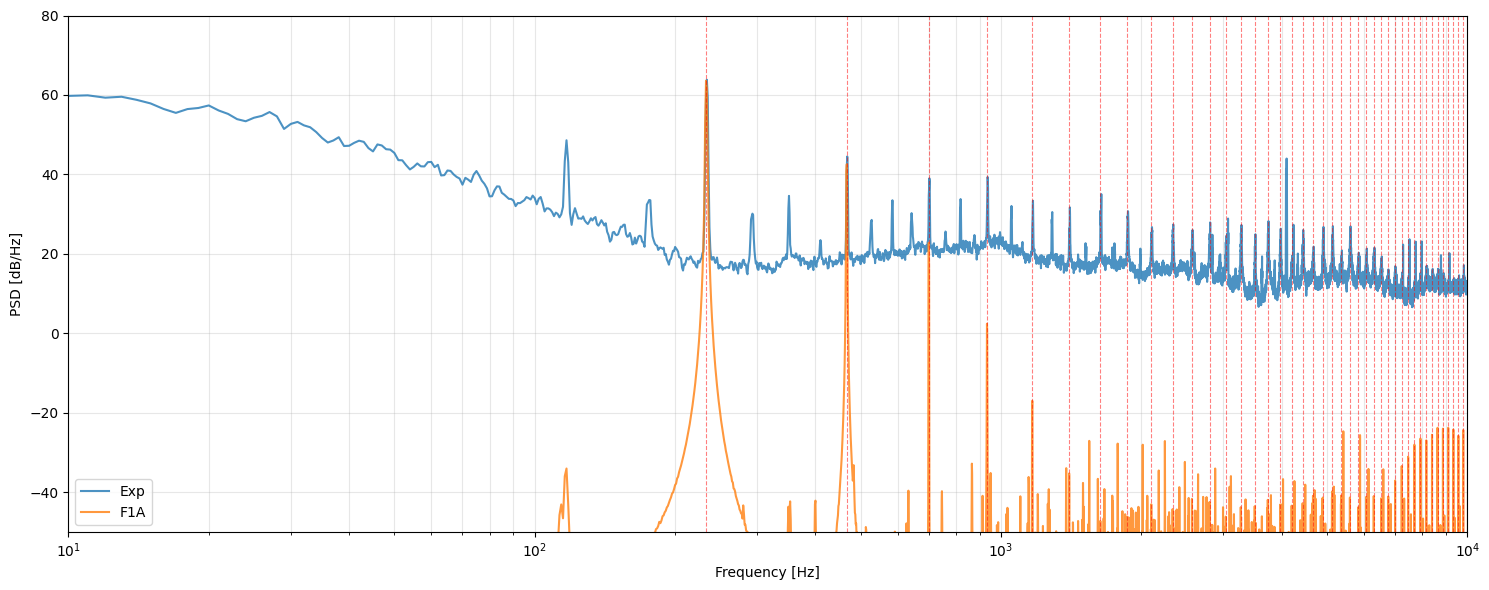

In [ ]:
from scipy import signal

fig, ax_spl = plt.subplots(figsize=(15, 6))

fontsize = 10
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

delta_f = 1

fs = 1 / dt
f_psd, pxx_den = signal.welch(p, fs, window='hann', nperseg=fs/delta_f, scaling='density')
psd_db_hz = 10 * np.log10(pxx_den / (p_ref**2))

fs_f1a_no_turb = 1 / (t_no_turb[1, 0] - t_no_turb[0, 0])
f_psd_f1a_no_turb, pxx_den_f1a_no_turb = signal.welch(p_no_turb[:, 0], fs_f1a_no_turb, window='hann', nperseg=fs_f1a_no_turb/delta_f, scaling='density')
psd_db_hz_f1a_no_turb = 10 * np.log10(pxx_den_f1a_no_turb / (p_ref**2))

fs_f1a = 1 / (propeller.t[1, 0] - propeller.t[0, 0])
f_psd_f1a, pxx_den_f1a = signal.welch(propeller.p_tot[:, 0], fs_f1a, window='hann', nperseg=fs_f1a/delta_f, scaling='density')
psd_db_hz_f1a = 10 * np.log10(pxx_den_f1a / (p_ref**2))

ax_spl.semilogx(f_psd, psd_db_hz, linestyle='-',
                    label='Exp', alpha=0.8)

ax_spl.semilogx(f_psd_f1a_no_turb, psd_db_hz_f1a_no_turb, linestyle='-',
                label='F1A No Turb', alpha=0.8)

ax_spl.semilogx(f_psd_f1a, psd_db_hz_f1a, linestyle='-',
                label='F1A', alpha=0.8)

ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('PSD [dB/Hz]', fontsize=fontsize)

blade_passing_freq = 1 / acoustic_params.blade_passing_period
max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    ax_spl.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
ax_spl.set_xlim(10, 10000)
ax_spl.set_ylim(-50,80)
plt.tight_layout()
plt.show()